In [1]:
# Essential libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import compute_zscore  # custom function for z-score calculation

# Inline plots
%matplotlib inline

In [2]:
# Select two stocks for pair trading
tickers = ["AAPL", "MSFT"]

# Download daily closing prices for 2023
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
data.dropna(inplace=True)  # remove missing values

# Preview the data
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,MSFT
Date,,
2023-01-03,123.211205,233.985641
2023-01-04,124.482048,223.750351
2023-01-05,123.161949,217.118912
2023-01-06,127.693581,219.677734
2023-01-09,128.215698,221.816574


In [3]:
# Compute the spread between the two stocks
data['spread'] = data[tickers[0]] - data[tickers[1]]

# Compute z-score of the spread
data['zscore'] = compute_zscore(data['spread'])

# Preview
data[['spread', 'zscore']].head()

Ticker,spread,zscore
Date,,
2023-01-03,-110.774437,1.071602
2023-01-04,-99.268303,1.530755
2023-01-05,-93.956963,1.742705
2023-01-06,-91.984154,1.821430
2023-01-09,-93.600876,1.756915


In [4]:
# Define entry and exit thresholds
entry_threshold = 1.0
exit_threshold = 0.0

# Initialize position column
data['position'] = 0

# Short spread if z-score > entry_threshold
data.loc[data['zscore'] > entry_threshold, 'position'] = -1

# Long spread if z-score < -entry_threshold
data.loc[data['zscore'] < -entry_threshold, 'position'] = 1

# Carry forward positions until exit
data['position'] = data['position'].ffill()
data.loc[data['zscore'].abs() < exit_threshold, 'position'] = 0

# Preview
data[['spread', 'zscore', 'position']].head(10)

Ticker,spread,zscore,position
Date,,,
2023-01-03,-110.774437,1.071602,-1
2023-01-04,-99.268303,1.530755,-1
2023-01-05,-93.956963,1.742705,-1
2023-01-06,-91.984154,1.821430,-1
2023-01-09,-93.600876,1.756915,-1
2023-01-10,-94.719116,1.712291,-1
2023-01-11,-98.758560,1.551097,-1
2023-01-12,-101.513351,1.441167,-1
2023-01-13,-100.886627,1.466176,-1


In [5]:
# Compute daily spread returns
data['spread_returns'] = data['spread'].diff()

# Compute strategy returns
data['strategy_returns'] = data['position'].shift(1) * data['spread_returns']

# Compute cumulative strategy returns
data['cumulative_strategy_returns'] = data['strategy_returns'].cumsum()

# Preview
data[['spread_returns', 'strategy_returns', 'cumulative_strategy_returns']].head()

Ticker,spread_returns,strategy_returns,cumulative_strategy_returns
Date,,,
2023-01-03,NaN,NaN,NaN
2023-01-04,11.506134,-11.506134,-11.506134
2023-01-05,5.311340,-5.311340,-16.817474
2023-01-06,1.972809,-1.972809,-18.790283
2023-01-09,-1.616722,1.616722,-17.173561


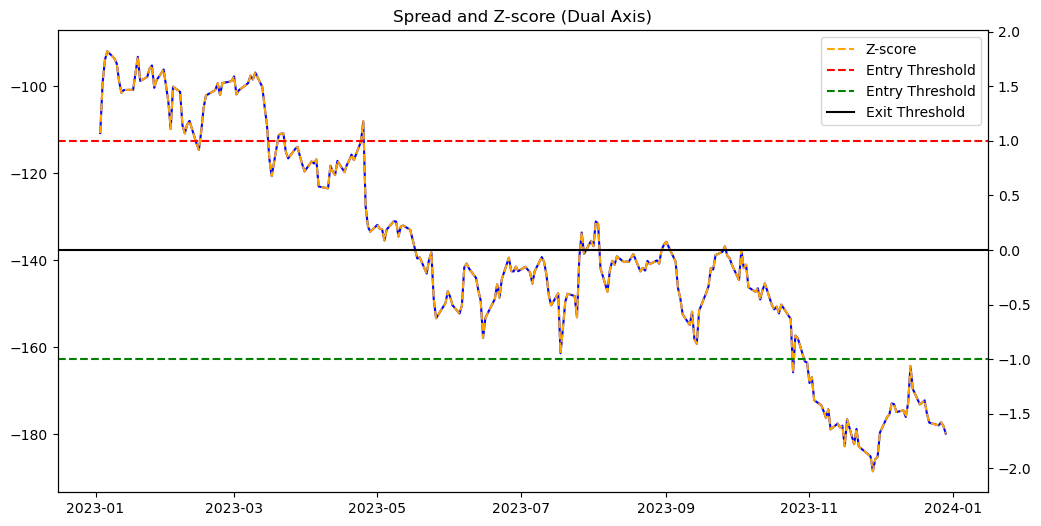

In [6]:
plt.figure(figsize=(12,6))

# Plot spread
plt.plot(data['spread'], color='blue', label='Spread')

# Create second y-axis for z-score
ax2 = plt.gca().twinx()
ax2.plot(data['zscore'], color='orange', label='Z-score', linestyle='--')

# Plot thresholds
ax2.axhline(entry_threshold, color='red', linestyle='--', label='Entry Threshold')
ax2.axhline(-entry_threshold, color='green', linestyle='--', label='Entry Threshold')
ax2.axhline(0, color='black', linestyle='-', label='Exit Threshold')

# Titles and legends
plt.title("Spread and Z-score (Dual Axis)")
plt.xlabel("Date")
plt.gca().legend(loc='upper left')
ax2.legend(loc='upper right')

# Save figure in figures/ folder
plt.savefig("figures/spread_zscore.png", bbox_inches='tight')

plt.show()

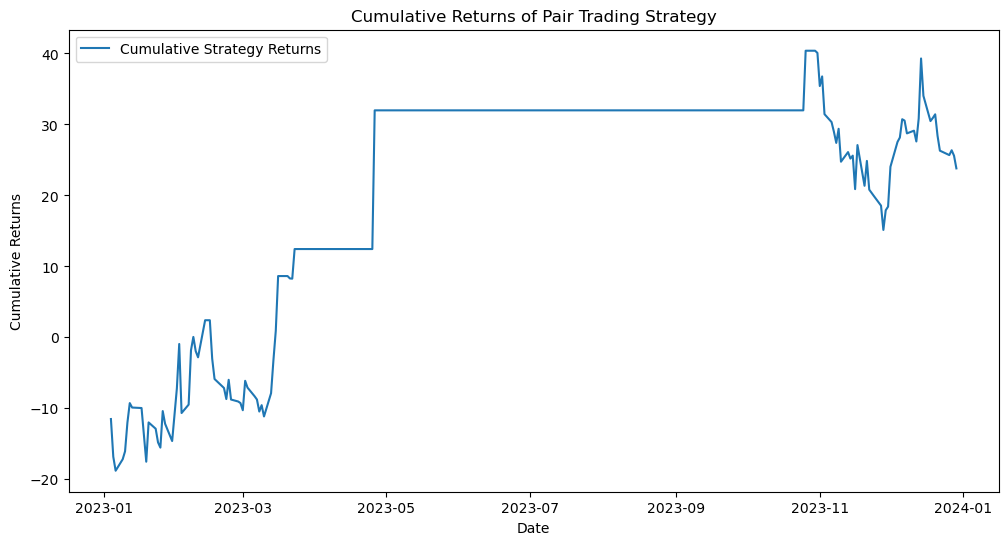

In [7]:
plt.figure(figsize=(12,6))
plt.plot(data['cumulative_strategy_returns'], label='Cumulative Strategy Returns')
plt.title("Cumulative Returns of Pair Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()

# Save figure in figures/ folder
plt.savefig("figures/cumulative_returns.png", bbox_inches='tight')

plt.show()